# Library

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.cluster as cluster
from sklearn import datasets
from imp import reload

# part I importing dataset

### 1) importing iris data

In [49]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/'       
                 'machine-learning-databases/iris/iris.data', header=None)

### 2) last 5 rows of the data

In [50]:
df.tail(5)

,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


# Part II - select Setosa and Versicolor

### 1) From the data set select setosa and versicolor. 

renaming the collumns so that there are no spaces (replacing spaces with '_')

In [51]:
df=df.rename(columns={0:"sepal_length", 1:"sepal_width", 2:"petal_length", 3:"petal_width", 4: 'species'})
print(df)

     sepal_length  sepal_width  petal_length  petal_width          species
0             5.1          3.5           1.4          0.2      Iris-setosa
1             4.9          3.0           1.4          0.2      Iris-setosa
2             4.7          3.2           1.3          0.2      Iris-setosa
3             4.6          3.1           1.5          0.2      Iris-setosa
4             5.0          3.6           1.4          0.2      Iris-setosa
5             5.4          3.9           1.7          0.4      Iris-setosa
6             4.6          3.4           1.4          0.3      Iris-setosa
7             5.0          3.4           1.5          0.2      Iris-setosa
8             4.4          2.9           1.4          0.2      Iris-setosa
9             4.9          3.1           1.5          0.1      Iris-setosa
10            5.4          3.7           1.5          0.2      Iris-setosa
11            4.8          3.4           1.6          0.2      Iris-setosa
12            4.8        

In [52]:
#removing the virginica which isnt needed
df = df.query('species == "Iris-setosa" | species == "Iris-versicolor"')
print(df)

    sepal_length  sepal_width  petal_length  petal_width          species
0            5.1          3.5           1.4          0.2      Iris-setosa
1            4.9          3.0           1.4          0.2      Iris-setosa
2            4.7          3.2           1.3          0.2      Iris-setosa
3            4.6          3.1           1.5          0.2      Iris-setosa
4            5.0          3.6           1.4          0.2      Iris-setosa
5            5.4          3.9           1.7          0.4      Iris-setosa
6            4.6          3.4           1.4          0.3      Iris-setosa
7            5.0          3.4           1.5          0.2      Iris-setosa
8            4.4          2.9           1.4          0.2      Iris-setosa
9            4.9          3.1           1.5          0.1      Iris-setosa
10           5.4          3.7           1.5          0.2      Iris-setosa
11           4.8          3.4           1.6          0.2      Iris-setosa
12           4.8          3.0         

### 2. improve the gradient descent do a feature scaling

In [53]:
sepal_length_std = (df.sepal_length - df.sepal_length.mean())/df.sepal_length.std()
petal_length_std = (df.petal_length - df.petal_length.mean())/df.petal_length.std()
df_std = pd.DataFrame({'sepal_length':sepal_length_std, 'petal_length':petal_length_std, 'species':df.species})
df_std

,sepal_length,petal_length,species
0,-0.578153,-1.009275,Iris-setosa
1,-0.889826,-1.009275,Iris-setosa
2,-1.201499,-1.078309,Iris-setosa
3,-1.357336,-0.940241,Iris-setosa
4,-0.733990,-1.009275,Iris-setosa
5,-0.110644,-0.802173,Iris-setosa
6,-1.357336,-1.009275,Iris-setosa
7,-0.733990,-0.940241,Iris-setosa
8,-1.669009,-1.009275,Iris-setosa
9,-0.889826,-0.940241,Iris-setosa


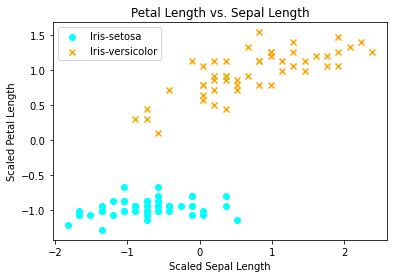

In [54]:
setosa = df_std.query('species == "Iris-setosa"')
versicolor = df_std.query('species == "Iris-versicolor"')
plt.scatter(setosa.sepal_length, setosa.petal_length, color='cyan', marker='o', label='Iris-setosa')
plt.scatter(versicolor.sepal_length, versicolor.petal_length, color='orange', marker='x', label='Iris-versicolor')
plt.legend(loc = 'best')
plt.xlabel('Scaled Sepal Length')
plt.ylabel('Scaled Petal Length')
plt.title('Petal Length vs. Sepal Length')
plt.show()

In [55]:
phi = {'species' : {'Iris-setosa':-1, 'Iris-versicolor':1}}
df_std = df_std.replace(phi)

# Part III – Implementation of Adaline 

## - turning the adaline Object oriented program into several different functions

In [56]:
def weight(y, xj):
    summ = 0
    for c in range(y.size):
        phi = weights[0] * x_0 + weights[1] * x_1[c] + weights[2] * x_2[c]
        summ += (y[c]-phi)*xj[c]
    d_w = learn_rate * summ
    return d_w

def weight_0(y, xj):
    summ = 0
    for c in range(y.size):
        phi_c = weights[0] * x_0 + weights[1] * x_1[c] + weights[2] * x_2[c]
        summ += (y[c]-phi_c)*xj
    d_w = learn_rate * summ
    return d_w

def cost(weights, yi):
    sum_cost = 0
    for i in range(yi.size):
        phi = weights[0] * x_0 + weights[1] * x_1[i] + weights[2] * x_2[i]
        sum_cost += (yi[i]-phi)**2
    msd = (1/yi.size)*(sum_cost)
    return msd
    
def epoch(weights):
    err = 0
    erf = cost(weights, y_i)
    diff_w[0] = weight_0(y_i, x_0)
    diff_w[1] = weight(y_i, x_1)
    diff_w[2] = weight(y_i, x_2)
    weights += diff_w
    # err += diff_w.sum()
    return erf

def unit_step(weights, x0, x1, x2):
    z = weights[0] * x0 + weights[1] * x1 + weights[2] * x2
    if z >= 0:
        label = 1
    else:
        label = -1
    return label

## Implemeting the Adaline algorithm to your data set with learning rate of 0.01.

In [57]:
weights = np.array([0,0,0], dtype='float')
diff_w = np.array([0,0,0], dtype='float')
learn_rate = 0.01
phi = 0
x_0 = 1
x_1 = df_std.sepal_length
x_2 = df_std.petal_length
y_i = df_std.species 

ep = np.array([])
er = np.array([])
ef = np.array([0])
n = 0
while True:
    ecf = epoch(weights)
    ep = np.append(ep, n)
    ef = np.append(ef, ecf)
    print(n, ecf)
    if abs(ecf-ef[n]) < 0.001:
        break
    n += 1
ef = np.delete(ef, 0)

0 1.0
1 0.653844864276161
2 0.43378303060251666
3 0.29383666407505443
4 0.20480871363579625
5 0.14815297159750934
6 0.1120851998465991
7 0.08911538053383371
8 0.07448135431612493
9 0.06515432835322141
10 0.0592072893433045
11 0.05541377462764657
12 0.05299290572591993
13 0.051447315415703264
14 0.05046009033055382


## Plotting the mean squared deviation vs. epoch

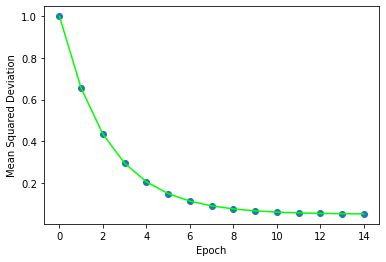

In [58]:
def plot_epoch():
    
    plt.plot(ep, ef, color='lime')
    plt.scatter(ep, ef)
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Deviation')
    plt.show()
    
plot_epoch()

the algorithm does not converge too fast or slow. 

14 epochs were done for the MSD to converge at the same order as the learning rate

In [59]:
pd.set_option("display.max_rows", None, "display.max_columns", None)
predict_label = np.array([])

for i in range(df_std.sepal_length.size):
    predict_label = np.append(predict_label, unit_step(weights, x_0, df_std.sepal_length[i], df_std.petal_length[i]))

compare = pd.DataFrame({'actual_label':df_std.species, 'predicted_label':predict_label})

Phi = {-1:'Setosa', 1:'Versicolor'}
compare = compare.replace(Phi)
print(compare)

   actual_label predicted_label
0        Setosa          Setosa
1        Setosa          Setosa
2        Setosa          Setosa
3        Setosa          Setosa
4        Setosa          Setosa
5        Setosa          Setosa
6        Setosa          Setosa
7        Setosa          Setosa
8        Setosa          Setosa
9        Setosa          Setosa
10       Setosa          Setosa
11       Setosa          Setosa
12       Setosa          Setosa
13       Setosa          Setosa
14       Setosa          Setosa
15       Setosa          Setosa
16       Setosa          Setosa
17       Setosa          Setosa
18       Setosa          Setosa
19       Setosa          Setosa
20       Setosa          Setosa
21       Setosa          Setosa
22       Setosa          Setosa
23       Setosa          Setosa
24       Setosa          Setosa
25       Setosa          Setosa
26       Setosa          Setosa
27       Setosa          Setosa
28       Setosa          Setosa
29       Setosa          Setosa
30      

## Plotting the clustered data set using a 2D-colormap graph where the color indicates the predicted output and the x- and y-axes are the features. 

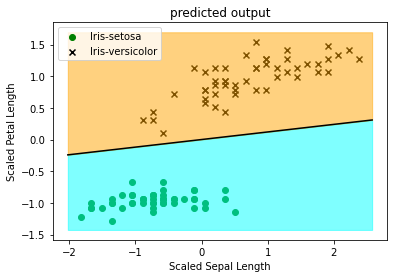

In [60]:
# create boundary line with weights
n_new = np.linspace(df_std.sepal_length.min() - 0.2, df_std.sepal_length.max() + 0.2, 10)
y_line = np.array([], dtype='float')
for n in n_new:
    y = -(weights[1]/weights[2])*n - (weights[0]/weights[2])*x_0
    y_line = np.append(y_line, y)
    
# combine plot with boundary line
plt.scatter(setosa.sepal_length, setosa.petal_length, color='green', marker='o', label='Iris-setosa')
plt.scatter(versicolor.sepal_length, versicolor.petal_length, color='black', marker='x', label='Iris-versicolor')
plt.fill_between(n_new, y_line, plt.gca().get_ylim()[0], color='cyan', alpha=.5)
plt.fill_between(n_new, y_line, plt.gca().get_ylim()[1], color='orange', alpha=.5)
plt.plot(n_new, y_line, color = 'black')
plt.legend(loc = 'best')
plt.xlabel('Scaled Sepal Length')
plt.ylabel('Scaled Petal Length')
plt.title('predicted output')
plt.show()